In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score


In [2]:
iris = datasets.load_iris()
X = iris.data[:, :2]
y = []
for e in iris.target:
    if e == 0:
        y.append(0)
    else:
        y.append(1)
y = np.array(y)

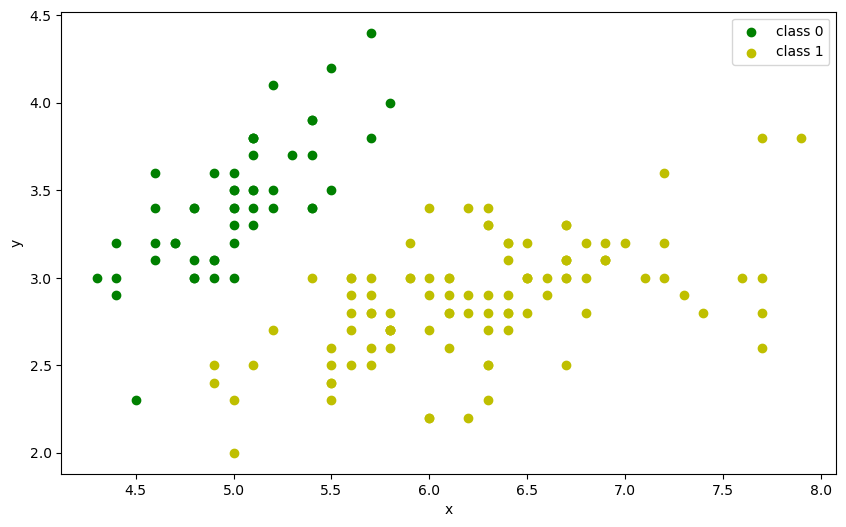

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(X[y==0][:,0], X[y==0][:,1], color='g')
plt.scatter(X[y==1][:,0], X[y==1][:,1], color='y')
plt.legend(labels=("class 0", "class 1"))
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [5]:

model = LogisticRegression(C=1e20)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model.fit(x_train, y_train)
score = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')
score1 = model.score(x_test, y_test)
score2 = model.score(x_train, y_train)
print("score sur test-set:", str(score1*100)+'%')
print("score sur train-set:", str(score2*100)+'%')

score sur test-set: 100.0%
score sur train-set: 100.0%


In [6]:
theta0 = model.intercept_
theta1, theta2 = model.coef_[0][0], model.coef_[0][1]
Iries_to_predict = np.array([[5.1, 3.5], [6.2, 3.4], [7.0, 3.2]])
print(model.predict(Iries_to_predict))

[0 1 1]


In [7]:
score=cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')
print(score)
print(score.mean())

[1.         1.         0.95833333 1.         1.        ]
0.9916666666666668


In [8]:
def fct_reg_logistic(x1,x2):
    z=(theta0)+theta1*x1+theta2*x2
    return z
print([fct_reg_logistic(e[0], e[1]) for e in Iries_to_predict])

[array([-67.7394864]), array([37.26816005]), array([125.69036207])]


step by step logistic regression

In [9]:
X = np.concatenate((X, np.ones((X.shape[0], 1))), axis=1)
theta = np.zeros(X.shape[1])
def h(theta,x):
    return 1/(1+np.exp(-np.dot(theta,x)))
def cost(x,y,theta):
    m = x.shape[0]
    s=0
    for i in range(m):
        s+=y[i]*np.log(h(theta,x[i]))+(1-y[i])*np.log(1-h(theta,x[i]))
    return -s/m

In [10]:
def grad(x,y,theta,j):
    m = x.shape[0]
    s=0
    for i in range(m):
        s+=(h(theta,x[i])-y[i])*x[i][j]
    return s/m

In [11]:
def gradient_descent(X,y,theta,learning_rate, n_iterations):
    historique_des_erreurs = []
    for i in range(n_iterations):
        H = np.array([h(theta,x) for x in X])
        Hy = [abs(H[i]-y[i]) for i in range(X.shape[0])]
        theta[0] = theta[0] - (learning_rate/X.shape[0])*sum(Hy)
        for j in range(X.shape[1]):
            theta[j] = theta[j] - learning_rate*grad(X,y,theta,j)
        historique_des_erreurs.append(cost(X,y,theta))
    return theta, historique_des_erreurs

In [12]:
n_iterations = 1000
learning_rate = 0.01
theta, historique_des_erreurs = gradient_descent(X, y, theta, learning_rate, n_iterations)
print(theta)
def h_with_bias(theta,x):
    XX = np.concatenate((np.array([1]), x), axis=0)
    return 1/(1+np.exp(-np.dot(theta,XX)))

[ 0.22493978 -0.32569918  0.2731421 ]


erreur de classification pour l'exemple 0
erreur de classification pour l'exemple 1
erreur de classification pour l'exemple 2
erreur de classification pour l'exemple 3
erreur de classification pour l'exemple 4
erreur de classification pour l'exemple 5
erreur de classification pour l'exemple 6
erreur de classification pour l'exemple 7
erreur de classification pour l'exemple 8
erreur de classification pour l'exemple 9
erreur de classification pour l'exemple 10
erreur de classification pour l'exemple 11
erreur de classification pour l'exemple 12
erreur de classification pour l'exemple 13
erreur de classification pour l'exemple 14
erreur de classification pour l'exemple 15
erreur de classification pour l'exemple 16
erreur de classification pour l'exemple 17
erreur de classification pour l'exemple 18
erreur de classification pour l'exemple 19
erreur de classification pour l'exemple 20
erreur de classification pour l'exemple 21
erreur de classification pour l'exemple 22
erreur de classificat

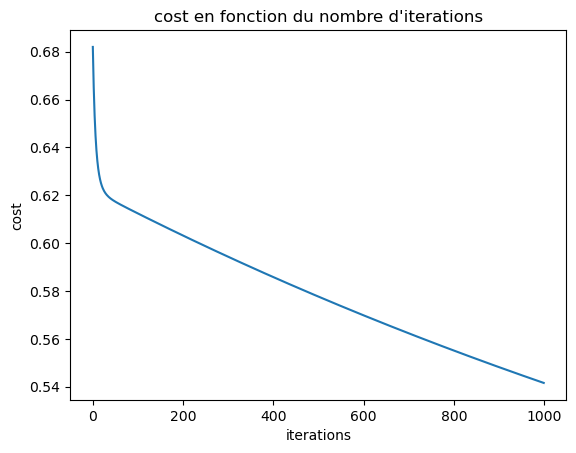

In [14]:
cpt = 0
for i in range(y.shape[0]):
    t = h(theta, X[i])
    if t<0.5:
        target = 0
    else:
        target = 1
    if target == y[i]:
        cpt+=1
    else:
        print("erreur de classification pour l'exemple", i)
print("taux de bonne classification:", str(cpt/y.shape[0]*100)+'%')
plt.plot(range(n_iterations), historique_des_erreurs)
plt.xlabel("iterations")
plt.ylabel("cost")
plt.title("cost en fonction du nombre d'iterations")
plt.show()